In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("./input/country_results.csv")

Os dados com que estamos trabalhando referem-se aos resultados de cada país participante da Olimpíada Internacional de Matemática (IMO) ao longo dos anos de 1959 - 2024. Cada linha da tabela abaixo traz informações sobre a participação de um país em uma edição específica da competição. Cada coluna representa um possível dado nesse contexto, sendo eles: 
- ano da edição (year): variável numérica discreta;
- país participante (country): variável categórica nominal;
- quantidade de participantes da equipe (team_size_all): variável numérica discreta;
- quantidade de participantes masculinos da equipe (team_size_male): variável numérica discreta;
- quantidade de participantes femininos da equipe (team_size_female): variável numérica discreta;
- pontuação acumulada da equipe em cada problema respectivo da prova (p1, p2, ..., p7): variável numérica discreta;
- quantidade de medalhas de ouro, prata ou bronze e quantidade de menções honrosas conferidas à equipe (awards_gold, awards_silver, awards_bronze, awards_honorable_mentions): variável numérica discreta;
- nome completo do líder da equipe (leader): variável categórica nominal;
- nome completo do vice-líder da equipe (deputy_leader): variável categórica nominal.


Valores com informações faltantes são marcadas com "NA".

In [4]:
display(data)

,year,country,team_size_all,team_size_male,team_size_female,p1,p2,p3,p4,p5,p6,p7,awards_gold,awards_silver,awards_bronze,awards_honorable_mentions,leader,deputy_leader
0,2024,United States of America,6,5.0,1.0,42.0,41.0,19.0,40.0,35.0,15.0,NaN,5.0,1.0,0.0,0.0,John Berman,Carl Schildkraut
1,2024,People's Republic of China,6,6.0,0.0,42.0,42.0,31.0,40.0,22.0,13.0,NaN,5.0,1.0,0.0,0.0,Liang Xiao,Yijun Yao
2,2024,Republic of Korea,6,6.0,0.0,42.0,37.0,18.0,42.0,7.0,22.0,NaN,2.0,4.0,0.0,0.0,Suyoung Choi,Hwajong Yoo
3,2024,India,6,6.0,0.0,42.0,34.0,11.0,42.0,28.0,10.0,NaN,4.0,1.0,0.0,1.0,Krishnan Sivasubramanian,Rijul Saini
4,2024,Belarus,6,6.0,0.0,42.0,30.0,10.0,42.0,36.0,5.0,NaN,4.0,0.0,2.0,0.0,David Zmiaikou,Dzmitry Bazyleu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,1959,Czechoslovakia,8,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,NaN,Rudolf Zelinka,NaN
3776,1959,Bulgaria,8,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Stoian Budurov,NaN
3777,1959,Poland,8,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,Mieczyslaw Czyżykowski,NaN
3778,1959,Union of Soviet Socialist Republics,4,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,Anatol Mikhailovitch Vladimirski,NaN


A fim de possuirmos variáveis de todos os 4 tipos possíveis para esse estudo, iremos derivar duas novas variáveis a partir desses dados:
- proporção de participantes femininos na equipe (female_proportion): variável numérica contínua;
- maturidade da equipe em concentrar-se somente nas fáceis ou garantir pontos nas difíceis (team_approach): variável categórica ordinal.

In [5]:
data["female_rate"] = data["team_size_female"]/data["team_size_all"]

max = 7*data["team_size_all"]*2
p_easy = (data["p1"]+data["p4"])/max
p_medium = (data["p2"]+data["p5"])/max
p_hard = (data["p3"]+data["p6"])/max

thresholds = [
    (p_easy >= 0.8) & (p_medium >= 0.5) & (p_hard >= 0.2),
    (p_easy >= 0.8) & (p_medium >= 0.5),
    (p_easy >= 0.8),
]

values = [3, 2, 1]

data["team_approach"] = np.select(thresholds, values, default=0)

In [ ]:
with pd.option_context("display.max_rows", None):
    display(data[["year", "country", "team_approach"]])

1.2. Uma seção sobre gráficos univariados para ao menos uma variável de cada tipo (qualitativa nominal, qualitativa  ordinal, quantitativa discreta, quantitativa contínua);


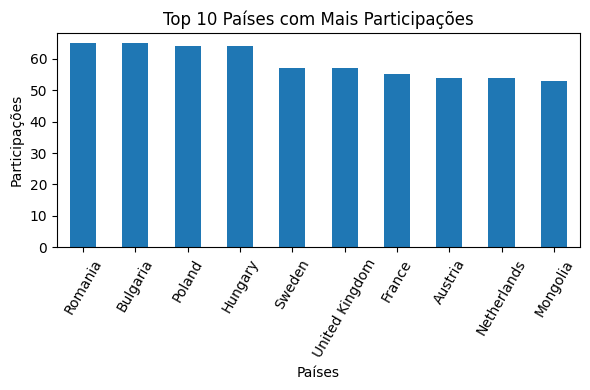

In [7]:
# VARIÁVEL QUALITATIVA NOMINAL

paises = data['country'].value_counts().head(10) #conta quantas vezes cada país aparece e pega os 10 primeiros
paisesplot = paises.plot(kind='bar', figsize=(6,4), title='Top 10 Países com Mais Participações',fontsize=10, rot= 60); #gera o gráfico de barras
#legendas dos eixos
plt.xlabel('Países');
plt.ylabel('Participações');

plt.tight_layout()
plt.show()

Aqui vemos os 10 páises que mais participam da competição, todos localizados na Europa.

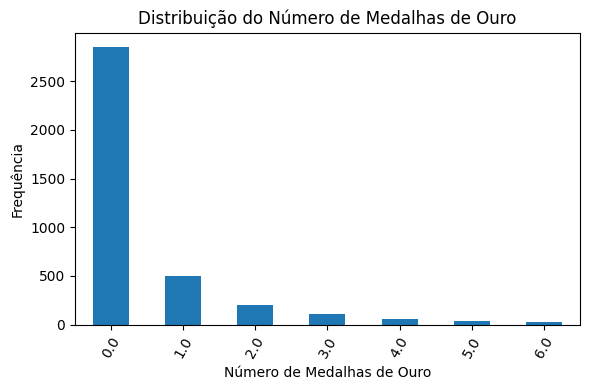

In [8]:
#VARIÁVEL QUANTITATIVA DISCRETA

ouros = data['awards_gold'].value_counts().sort_index() #conta quantas vezes cada número de medalhas de ouro aparece e ordena
ourosplot = ouros.plot(kind='bar', figsize=(6,4), title='Distribuição do Número de Medalhas de Ouro',fontsize=10, rot= 60); #gera o gráfico de barras
# legendas dos eixos
plt.xlabel('Número de Medalhas de Ouro');
plt.ylabel('Frequência');

plt.tight_layout()
plt.show()

Ao analisarmos o gráfico é possivel ver o imenso nível de dificuldade da IMO, onde a frêquencia de equipes que não conseguem nenhuma medalha de ouro na competição é imensamente maior do que as que conseguem pelo menos uma medalha.

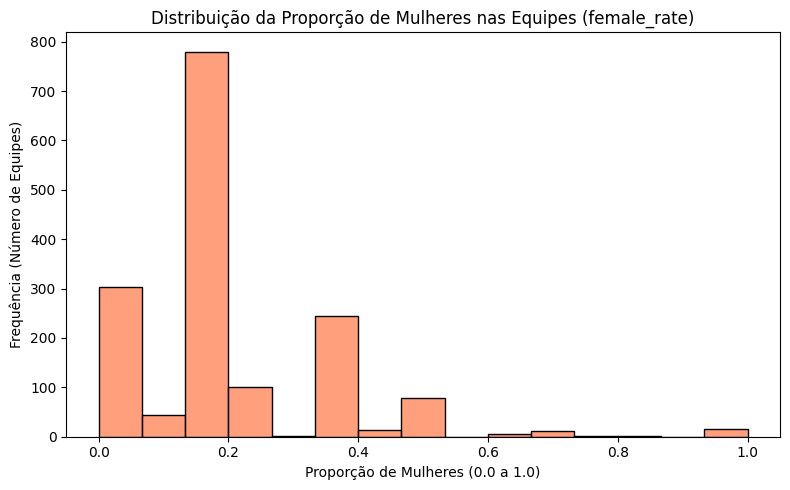

In [9]:
#QUANTITATIVA CONTÍNUA

plt.figure(figsize=(8, 5)) # tamanho da figura

sns.histplot(data["female_rate"].dropna(), bins=15, color='coral', edgecolor='black') # gera o gráfico de histograma

#titulos
plt.title('Distribuição da Proporção de Mulheres nas Equipes (female_rate)', fontsize=12)
plt.xlabel('Proporção de Mulheres (0.0 a 1.0)', fontsize=10)
plt.ylabel('Frequência (Número de Equipes)', fontsize=10)

plt.tight_layout()
plt.show()

Como vimos no gráfico, a maioria absoluta das equipes tem uma proporção em torno de 0.0 a 0.2, ou seja, de 0 a 20% da equipe com participação feminina. O pico ocorre por volta do 0.1 e 0.15, o que corresponde a 1 mulher em uma equipe de 6 pessoas.

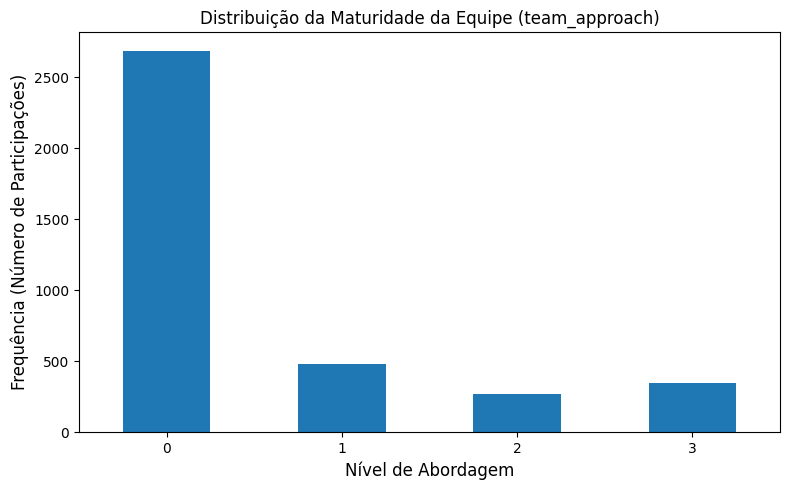

In [10]:
#QUALITATIVA ORDINAL

approach_counts = data["team_approach"].value_counts().sort_index() #conta quantas vezes cada nível de abordagem aparece e ordena

plt.figure(figsize=(8, 5)) # tamanho da figura

approachplot = approach_counts.plot(kind='bar', title= 'Distribuição da Maturidade da Equipe (team_approach)', rot=0) # gera o gráfico de barras
#legenda
plt.xlabel('Nível de Abordagem', fontsize=12)
plt.ylabel('Frequência (Número de Participações)', fontsize=12)


plt.tight_layout()
plt.show()

Ao analisarmos o gráfico, vemos que o nivel de abordagem com 0 maturidade é extremamente grande, o que indica que a imensa maioria das equipes não conseguem resolver de forma consistente nem as duas questões "fáceis" da prova. Com o nível de maturidade 3 ocorre um fenomeno interessante, cusiosamente há mais ocorrencias no nivel 3 do que no nível 2. Isso indica que, quando um páis atinge maturidade de teinamento para quase gabaritar as fáceis e resolver as médias, os alunos dessa equipe também tem nível e preparo para pontuar nas questões mais difíceis da competição.

1.3. Uma seção sobre análise bivariada, com ao menos uma distribuição de frequências e uma figura bivariadas;


In [13]:
top_10_ouro = data.groupby('country')['awards_gold'].sum().sort_values(ascending=False).head(10)

display(top_10_ouro)

country
People's Republic of China             185.0
United States of America               151.0
Russian Federation                     106.0
Republic of Korea                       95.0
Hungary                                 88.0
Romania                                 86.0
Union of Soviet Socialist Republics     77.0
Vietnam                                 69.0
Bulgaria                                57.0
United Kingdom                          56.0
Name: awards_gold, dtype: float64

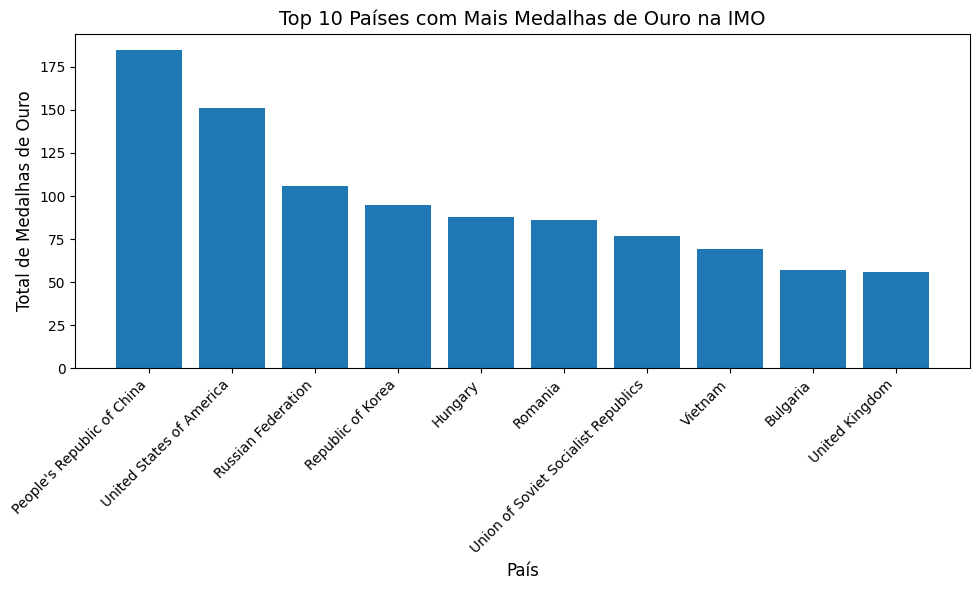

In [14]:
plt.figure(figsize=(10, 6))
barras = plt.bar(top_10_ouro.index, top_10_ouro.values)

plt.title('Top 10 Países com Mais Medalhas de Ouro na IMO', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Total de Medalhas de Ouro', fontsize=12)
           
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()